# <font color='#BFD72F' size=6>**0. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [9]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import requests
from river import (compose, ensemble, linear_model, metrics, naive_bayes, stats, tree, utils,)

# <font color='#BFD72F' size=6>**1. Data Collection**</font> <a class="anchor" id="1"></a>

- 1.1 Save original API response
- 1.2 Extract hourly observations into a DataFrame
- 1.3 Convert the timestamp column into datetime
- 1.4 Sort observations chronologically
- 1.5 historical period: **Year 2023**
- 1.6 Save processed data

[Back to TOC](#toc)

In [3]:
# Project configuration

START_DATE = "2023-01-01"
END_DATE = "2023-12-31"
TIMEZONE = "Europe/Lisbon"

WARMUP_PERCENTAGE = 0.15
HOT_PERCENTILE = 0.80
MIN_CONSECUTIVE_HOT_DAYS = 3

WINDOW_SIZE = 24 * 30  # 30 days, measured in hourly observations
RANDOM_SEED = 42

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")

for directory in [RAW_DIR, PROCESSED_DIR, RESULTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CITIES = {
    "Aveiro": {
        "latitude": 40.6405,
        "longitude": -8.6538,
    },
    "Viseu": {
        "latitude": 40.6572,
        "longitude": -7.9142,
    },
}

WEATHER_COLUMNS = [
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
]

PHYSICAL_BOUNDS = {
    "temperature": (-10.0, 50.0),
    "humidity": (0.0, 100.0),
    "precipitation": (0.0, 150.0),
    "wind_speed": (0.0, 150.0),
}

print("Configuration loaded.")

Configuration loaded.


In [4]:
def fetch_open_meteo_data(
    latitude: float,
    longitude: float,
    start_date: str,
    end_date: str,
    city_name: str,
) -> pd.DataFrame:
    """Fetch hourly observations and save raw and processed data."""

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "wind_speed_10m",
        ],
        "timezone": TIMEZONE,
    }

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    data = response.json()

    # Save original response
    raw_path = RAW_DIR / f"{city_name.lower()}.json"

    with raw_path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2)

    if "hourly" not in data or "time" not in data["hourly"]:
        raise ValueError(f"Invalid hourly API response for {city_name}.")

    df = pd.DataFrame(data["hourly"])

    df = df.rename(
        columns={
            "temperature_2m": "temperature",
            "relative_humidity_2m": "humidity",
            "wind_speed_10m": "wind_speed",
        }
    )

    df["time"] = pd.to_datetime(df["time"])
    df["city"] = city_name

    df = df.sort_values("time").reset_index(drop=True)

    processed_path = PROCESSED_DIR / f"{city_name.lower()}.csv"
    df.to_csv(processed_path, index=False)

    print(
        f"{city_name}: {len(df):,} observations saved "
        f"to {processed_path}"
    )

    return df

weather_data = {}

for city_name, location in CITIES.items():
    weather_data[city_name] = fetch_open_meteo_data(
        latitude=location["latitude"],
        longitude=location["longitude"],
        start_date=START_DATE,
        end_date=END_DATE,
        city_name=city_name,
    )

df_aveiro_raw = weather_data["Aveiro"]
df_viseu_raw = weather_data["Viseu"]

Aveiro: 8,760 observations saved to ..\data\processed\aveiro.csv
Viseu: 8,760 observations saved to ..\data\processed\viseu.csv


### Understand the data

Check observations before building the stream. 
- Invalid measurements are replaced with missing values, but missing values are not filled using future observations.

In [5]:
def audit_weather_data(
    df: pd.DataFrame,
    city_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Audit timestamps, missing values, and physical bounds."""

    result = df.copy()
    audit_records = []

    result["time"] = pd.to_datetime(result["time"])
    result = result.sort_values("time").reset_index(drop=True)

    duplicate_count = int(result["time"].duplicated().sum())

    if duplicate_count:
        audit_records.append({
            "city": city_name,
            "issue": "Duplicate timestamps",
            "variable": "time",
            "count": duplicate_count,
        })

        # Keep first observation for each timestamp
        result = result.drop_duplicates(
            subset="time",
            keep="first",
        ).reset_index(drop=True)

    for column, (lower, upper) in PHYSICAL_BOUNDS.items():
        invalid = (
            (result[column] < lower)
            | (result[column] > upper)
        )

        invalid_count = int(invalid.sum())

        if invalid_count:
            audit_records.append({
                "city": city_name,
                "issue": f"Outside physical bounds [{lower}, {upper}]",
                "variable": column,
                "count": invalid_count,
            })

            result.loc[invalid, column] = np.nan

    for column in WEATHER_COLUMNS:
        missing_count = int(result[column].isna().sum())

        if missing_count:
            audit_records.append({
                "city": city_name,
                "issue": "Missing values",
                "variable": column,
                "count": missing_count,
            })

    # Check hourly timeline
    expected_times = pd.date_range(
        start=result["time"].min(),
        end=result["time"].max(),
        freq="h",
    )

    missing_times = expected_times.difference(
        pd.DatetimeIndex(result["time"])
    )

    audit_records.append({
        "city": city_name,
        "issue": "Missing hourly timestamps",
        "variable": "time",
        "count": len(missing_times),
    })

    audit = pd.DataFrame(audit_records)

    return result, audit

clean_data = {}
audit_tables = []

for city_name, df in weather_data.items():
    clean_data[city_name], audit = audit_weather_data(
        df, city_name
    )

    audit_tables.append(audit)

audit_summary = pd.concat(audit_tables, ignore_index=True)

display(audit_summary)

for city_name, df in clean_data.items():
    print(f"\n{city_name}")
    print(f"Rows: {len(df):,}")
    print(f"Period: {df['time'].min()} to {df['time'].max()}")
    print("\nMissing values:")
    display(df[WEATHER_COLUMNS].isna().sum().to_frame("missing"))
    display(df[WEATHER_COLUMNS].describe().round(2))

,city,issue,variable,count
0,Aveiro,Missing hourly timestamps,time,0
1,Viseu,Missing hourly timestamps,time,0



Aveiro
Rows: 8,760
Period: 2023-01-01 00:00:00 to 2023-12-31 23:00:00

Missing values:


,missing
temperature,0
humidity,0
precipitation,0
wind_speed,0


,temperature,humidity,precipitation,wind_speed
count,8760.00,8760.00,8760.00,8760.00
mean,15.98,80.40,0.13,13.63
std,4.93,15.61,0.61,8.10
min,0.10,21.00,0.00,0.00
25%,13.00,71.00,0.00,7.10
50%,16.50,84.00,0.00,12.30
75%,19.30,93.00,0.00,18.50
max,33.20,100.00,15.50,48.30



Viseu
Rows: 8,760
Period: 2023-01-01 00:00:00 to 2023-12-31 23:00:00

Missing values:


,missing
temperature,0
humidity,0
precipitation,0
wind_speed,0


,temperature,humidity,precipitation,wind_speed
count,8760.00,8760.00,8760.00,8760.00
mean,14.85,72.53,0.14,10.12
std,7.12,21.50,0.61,6.03
min,-2.50,13.00,0.00,0.00
25%,9.80,58.00,0.00,5.40
50%,14.30,77.00,0.00,8.80
75%,19.30,91.00,0.00,14.00
max,40.20,100.00,12.70,41.30


In [7]:
def get_model_ready_data(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    # Security measure
    result = result.dropna(
        subset=WEATHER_COLUMNS)
    result = result.sort_values("time").reset_index(drop=True)
    return result

clean_data = {
    city: get_model_ready_data(df)
    for city, df in clean_data.items()
}

for city, df in clean_data.items():
    print(f"{city}: {len(df):,} valid observations")

Aveiro: 8,760 valid observations
Viseu: 8,760 valid observations


### Estimate temperature threshold incrementally

Use first 15% of calendar days in each city's stream as the warm-up period. A River quantile estimator receives one completed daily maximum at a time. The threshold is then frozen.

In [10]:
def iter_daily_maxima(df: pd.DataFrame):
    """Yield one completed daily maximum at a time."""

    current_date = None
    current_max = None

    for row in df.sort_values("time").itertuples(index=False):
        timestamp = pd.Timestamp(row.time)
        day = timestamp.normalize()
        temperature = float(row.temperature)

        if current_date is None:
            current_date = day
            current_max = temperature

        elif day == current_date:
            current_max = max(current_max, temperature)

        else:
            # previous day is complete.
            yield current_date, current_max

            current_date = day
            current_max = temperature

    # Final day is complete at end-of-stream, assuming the input
    # covers that day's full observation period.
    if current_date is not None:
        yield current_date, current_max

def get_warmup_end(df: pd.DataFrame) -> pd.Timestamp:
    """Find the end date of the initial warm-up portion."""

    dates = pd.DatetimeIndex(
        df["time"].dt.normalize().drop_duplicates()
    ).sort_values()

    warmup_days = max(
        1,
        int(np.ceil(len(dates) * WARMUP_PERCENTAGE)),
    )

    return dates[warmup_days - 1]


warmup_ends = {
    city: get_warmup_end(df)
    for city, df in clean_data.items()
}

print("Warm-up end dates:")
for city, date in warmup_ends.items():
    print(f"{city}: {date.date()}")


def estimate_threshold_incrementally(
    city_data: dict[str, pd.DataFrame],
    warmup_ends: dict[str, pd.Timestamp],
) -> tuple[float, int]:
    """Estimate the pooled warm-up percentile online."""

    quantile = stats.Quantile(q=HOT_PERCENTILE)
    observations_seen = 0

    for city, df in city_data.items():
        warmup_end = warmup_ends[city]

        # Only observations belonging to the warm-up period are used.
        warmup_df = df.loc[
            df["time"].dt.normalize() <= warmup_end
        ]

        # Each daily maximum updates the online quantile estimator.
        for _, daily_max in iter_daily_maxima(warmup_df):
            quantile.update(daily_max)
            observations_seen += 1

    if observations_seen == 0:
        raise ValueError("The warm-up period contains no valid daily maxima.")

    return float(quantile.get()), observations_seen


TAU_T_HOT, N_WARMUP_DAYS = estimate_threshold_incrementally(
    clean_data,
    warmup_ends,
)

print(f"\nFrozen hot-day threshold: {TAU_T_HOT:.2f} °C")
print(f"Warm-up daily maxima processed: {N_WARMUP_DAYS}")

Warm-up end dates:
Aveiro: 2023-02-24
Viseu: 2023-02-24

Frozen hot-day threshold: 15.42 °C
Warm-up daily maxima processed: 110


### Build online heat-wave detector

In [11]:
class OnlineHeatwaveDetector:
    """Stateful detector for consecutive hot days in an hourly stream."""

    def __init__(
        self,
        threshold: float,
        min_consecutive_days: int = 3,
    ):
        self.threshold = threshold
        self.min_consecutive_days = min_consecutive_days

        self.current_date = None
        self.current_day_max = None
        self.previous_completed_date = None
        self.consecutive_hot_days = 0
        self.heatwave_active = False

    def _finish_day(self):
        """Finalize the current day when the next day begins."""

        completed_date = self.current_date
        completed_max = self.current_day_max

        if self.previous_completed_date is not None:
            day_gap = (
                completed_date - self.previous_completed_date
            ).days

            if day_gap != 1:
                # a missing calendar day breaks the consecutive run
                self.consecutive_hot_days = 0
                self.heatwave_active = False

        hot_day = completed_max >= self.threshold

        if hot_day:
            self.consecutive_hot_days += 1
        else:
            self.consecutive_hot_days = 0
            self.heatwave_active = False

        if self.consecutive_hot_days >= self.min_consecutive_days:
            self.heatwave_active = True

        self.previous_completed_date = completed_date

        return completed_date, completed_max, hot_day

    def update(self, timestamp, temperature):
        """Consume one observation and return the current detector state."""

        timestamp = pd.Timestamp(timestamp)
        day = timestamp.normalize()
        temperature = float(temperature)

        completed_day = None

        if self.current_date is None:
            self.current_date = day
            self.current_day_max = temperature

        elif day == self.current_date:
            self.current_day_max = max(
                self.current_day_max,
                temperature,
            )

        else:
            completed_day = self._finish_day()

            self.current_date = day
            self.current_day_max = temperature

        return {
            "time": timestamp,
            "daily_max_so_far": self.current_day_max,
            "completed_day": (
                completed_day[0] if completed_day else pd.NaT
            ),
            "completed_day_max": (
                completed_day[1] if completed_day else np.nan
            ),
            "hot_day_confirmed": (
                completed_day[2] if completed_day else None
            ),
            "heatwave_active": int(self.heatwave_active),
        }


def label_stream_online(
    df: pd.DataFrame,
    threshold: float,
    warmup_end: pd.Timestamp,
) -> pd.DataFrame:
    """
    Replay observations after warm-up and generate causal alert labels.

    The detector begins with no prior hot-day history. It does not
    backdate an alert to days before the event was confirmed.
    """

    stream = df.loc[
        df["time"].dt.normalize() > warmup_end
    ].copy()

    stream = stream.sort_values("time").reset_index(drop=True)

    detector = OnlineHeatwaveDetector(
        threshold=threshold,
        min_consecutive_days=MIN_CONSECUTIVE_HOT_DAYS,
    )

    records = []

    for row in stream.itertuples(index=False):
        records.append(
            detector.update(row.time, row.temperature)
        )

    labels = pd.DataFrame(records)

    result = stream.merge(
        labels,
        on="time",
        how="left",
        validate="one_to_one",
    )

    result["target"] = result["heatwave_active"].astype(int)

    return result


labeled_data = {}

for city, df in clean_data.items():
    labeled_data[city] = label_stream_online(
        df,
        threshold=TAU_T_HOT,
        warmup_end=warmup_ends[city],
    )

    result = labeled_data[city]

    print(f"\n{city}")
    print(result["target"].value_counts().sort_index())
    print(f"Detected-alert hours: {result['target'].sum():,}")


Aveiro
target
0    1224
1    6216
Name: count, dtype: int64
Detected-alert hours: 6,216

Viseu
target
0    2448
1    4992
Name: count, dtype: int64
Detected-alert hours: 4,992


### Visualize detector output

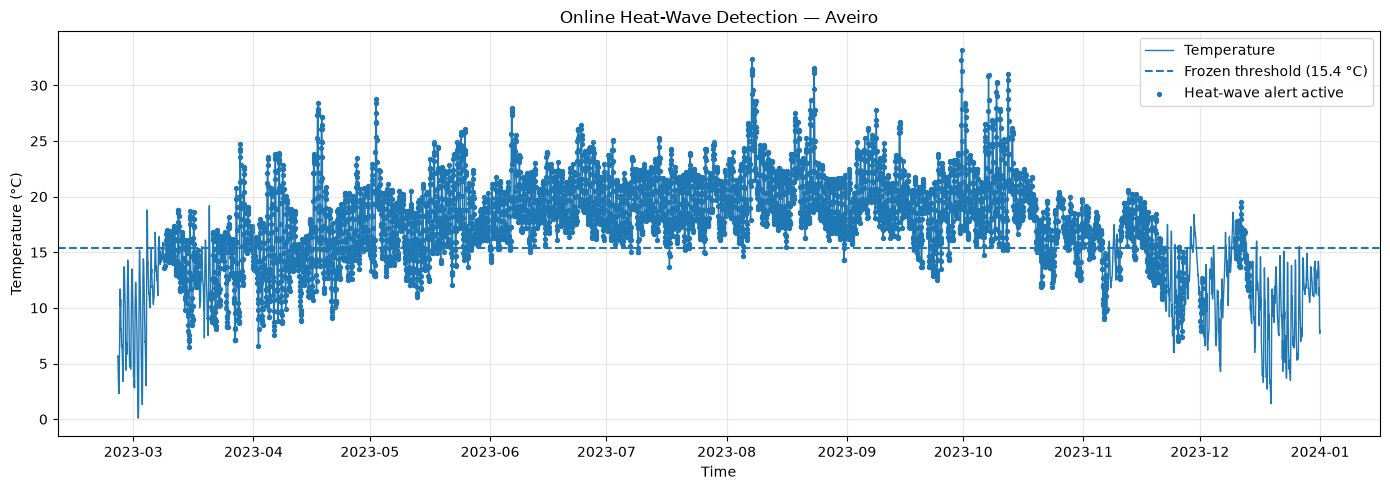

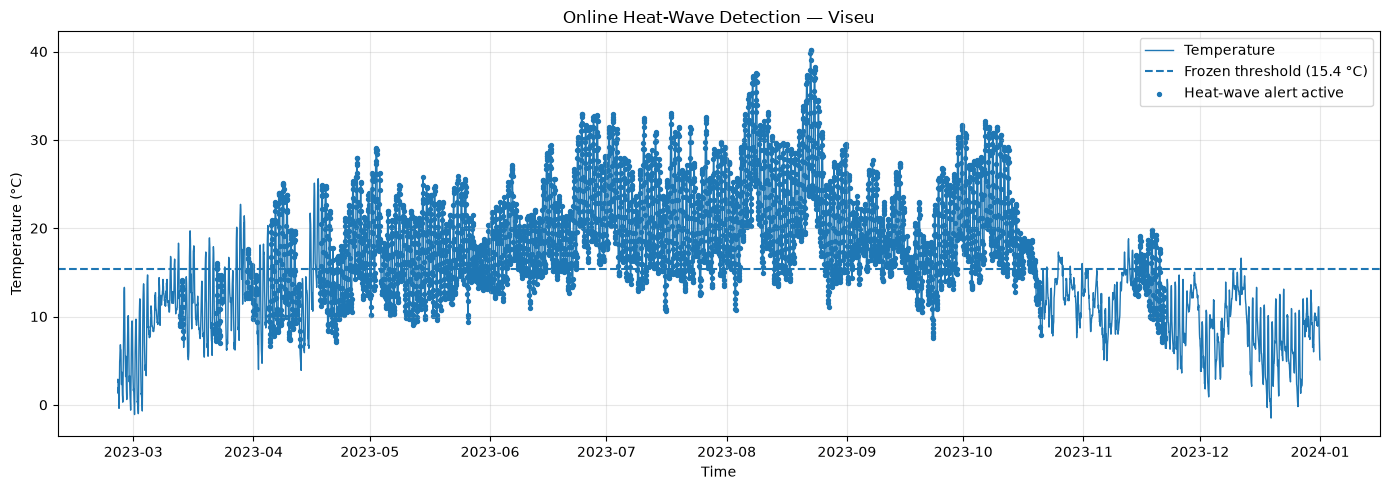

In [12]:
def plot_heatwave_detection(df: pd.DataFrame, city: str):
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        df["time"],
        df["temperature"],
        label="Temperature",
        linewidth=1,
    )

    ax.axhline(
        TAU_T_HOT,
        linestyle="--",
        label=f"Frozen threshold ({TAU_T_HOT:.1f} °C)",
    )

    detected = df["target"] == 1

    ax.scatter(
        df.loc[detected, "time"],
        df.loc[detected, "temperature"],
        label="Heat-wave alert active",
        s=8,
    )

    ax.set_title(f"Online Heat-Wave Detection — {city}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Temperature (°C)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


for city, df in labeled_data.items():
    plot_heatwave_detection(df, city)

### Create past-only features

The classifier predicts the current alert state using previous weather measurements. The current temperature is deliberately excluded from the features because it contributes to the detector state and could otherwise reveal the target too directly.

Representation A uses four lagged variables. Representation B adds historical temperature trends and variability.

In [13]:
FEATURE_COLS_A = [
    "temperature_lag1",
    "humidity_lag1",
    "precipitation_lag1",
    "wind_speed_lag1",
]

FEATURE_COLS_B = FEATURE_COLS_A + [
    "delta_temp",
    "rolling_mean_temp_6h",
    "rolling_std_temp_6h",
    "rolling_mean_temp_24h",
    "heat_events_last_24h",
]


def prepare_stream_features(df: pd.DataFrame) -> pd.DataFrame:
    """Build features from historical observations only."""

    result = df.sort_values("time").copy().reset_index(drop=True)

    # Historical measurements available before the current observation.
    for column in WEATHER_COLUMNS:
        result[f"{column}_lag1"] = result[column].shift(1)

    previous_temperature = result["temperature"].shift(1)

    result["delta_temp"] = (
        result["temperature"].shift(1)
        - result["temperature"].shift(2)
    )

    result["rolling_mean_temp_6h"] = (
        previous_temperature.rolling(6, min_periods=6).mean()
    )

    result["rolling_std_temp_6h"] = (
        previous_temperature.rolling(6, min_periods=6).std()
    )

    result["rolling_mean_temp_24h"] = (
        previous_temperature.rolling(24, min_periods=24).mean()
    )

    previous_hot = (
        result["temperature"].shift(1) >= TAU_T_HOT
    ).astype(float)

    result["heat_events_last_24h"] = (
        previous_hot.rolling(24, min_periods=24).sum()
    )

    # Remove observations without enough historical context.
    required = FEATURE_COLS_B + ["target"]

    result = result.dropna(subset=required).reset_index(drop=True)

    return result


stream_data = {
    city: prepare_stream_features(df)
    for city, df in labeled_data.items()
}

for city, df in stream_data.items():
    print(f"{city}: {len(df):,} usable stream observations")
    print(f"Alert prevalence: {df['target'].mean():.2%}")

Aveiro: 7,416 usable stream observations
Alert prevalence: 83.82%
Viseu: 7,416 usable stream observations
Alert prevalence: 67.31%


### Define River models

In [ ]:
def make_models():
    return {
        "Gaussian NB": naive_bayes.GaussianNB(),

        "Online Logistic Regression": compose.Pipeline(
            linear_model.LogisticRegression()
        ),

        "Hoeffding Tree": tree.HoeffdingTreeClassifier(),

        "Online Bagging": ensemble.BaggingClassifier(
            model=tree.HoeffdingTreeClassifier(),
            seed=RANDOM_SEED,
        ),
    }

### Prequential online evaluation

Each observation follows the same sequence:

1. Predict the current target.
2. Evaluate the prediction.
3. Update cumulative and rolling metrics.
4. Train the model on the observation.

In [15]:
def track_online_performance(
    df_stream: pd.DataFrame,
    feature_cols: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Evaluate River models using predict -> evaluate -> learn."""

    models = make_models()

    cumulative_metrics = {
        name: {
            "accuracy": metrics.Accuracy(),
            "precision": metrics.Precision(),
            "recall": metrics.Recall(),
            "f1": metrics.F1(),
            "macro_f1": metrics.MacroF1(),
        }
        for name in models
    }

    rolling_metrics = {
        name: utils.Rolling(
            metrics.MacroF1(),
            window_size=WINDOW_SIZE,
        )
        for name in models
    }

    records = []

    # Iterate in timestamp order, one observation at a time.
    for row in df_stream.itertuples(index=False):
        x = {
            column: float(getattr(row, column))
            for column in feature_cols
        }

        y = int(row.target)

        record = {"time": row.time}

        for name, model in models.items():
            # 1. Predict before learning.
            y_pred = model.predict_one(x)

            if y_pred is not None:
                # 2. Evaluate this prediction.
                for metric_name, metric in cumulative_metrics[name].items():
                    metric.update(y, y_pred)

                    record[f"{name} | {metric_name}"] = metric.get()

                rolling_metrics[name].update(y, y_pred)

                record[f"{name} | rolling_macro_f1"] = (
                    rolling_metrics[name].get()
                )

            else:
                for metric_name in cumulative_metrics[name]:
                    record[f"{name} | {metric_name}"] = np.nan

                record[f"{name} | rolling_macro_f1"] = np.nan

            # 3. Learn only after evaluating.
            model.learn_one(x, y)

        records.append(record)

    history = pd.DataFrame(records)

    final_scores = []

    for name in models:
        score = {"model": name}

        for metric_name, metric in cumulative_metrics[name].items():
            score[metric_name] = metric.get()

        score["rolling_macro_f1"] = rolling_metrics[name].get()
        final_scores.append(score)

    return history, pd.DataFrame(final_scores)

The model is learning to predict the detector's alert state. The detector and the classifier are separate components: the detector defines the target, and the classifier attempts to predict it from earlier weather measurements.

### Run experiments

In [16]:
experiments = {}
results = []

for city, df_stream in stream_data.items():
    for representation, feature_cols in [
        ("A", FEATURE_COLS_A),
        ("B", FEATURE_COLS_B),
    ]:
        experiment_name = f"{city} - Representation {representation}"

        print(f"Running: {experiment_name}")

        history, scores = track_online_performance(
            df_stream,
            feature_cols,
        )

        experiments[experiment_name] = history

        scores.insert(0, "representation", representation)
        scores.insert(0, "city", city)

        results.append(scores)

comparison = pd.concat(results, ignore_index=True)

display(
    comparison[
        [
            "city",
            "representation",
            "model",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "macro_f1",
            "rolling_macro_f1",
        ]
    ].round(3)
)

comparison.to_csv(
    RESULTS_DIR / "online_model_comparison.csv",
    index=False,
)

print(f"Results saved to {RESULTS_DIR / 'online_model_comparison.csv'}")

Running: Aveiro - Representation A


C:\Users\wwwnj\AppData\Local\Temp\ipykernel_6104\1288705788.py:21: DeprecationWarning: Passing an instance to utils.Rolling is deprecated and will be removed in a future release. Pass the class and forward constructor kwargs instead, e.g. utils.Rolling(stats.Mean, window_size=...) or utils.Rolling(stats.Var, window_size=..., ddof=0).
  name: utils.Rolling(


Running: Aveiro - Representation B
Running: Viseu - Representation A
Running: Viseu - Representation B


,city,representation,model,accuracy,precision,recall,f1,macro_f1,rolling_macro_f1
0,Aveiro,A,Gaussian NB,0.890,0.912,0.961,0.936,0.770,0.521
1,Aveiro,A,Online Logistic Regression,0.998,0.999,0.999,0.999,0.997,0.991
2,Aveiro,A,Hoeffding Tree,0.901,0.922,0.963,0.942,0.798,0.582
3,Aveiro,A,Online Bagging,0.915,0.939,0.961,0.950,0.835,0.689
4,Aveiro,B,Gaussian NB,0.952,0.982,0.961,0.971,0.915,0.890
5,Aveiro,B,Online Logistic Regression,0.998,0.999,0.999,0.999,0.997,0.991
6,Aveiro,B,Hoeffding Tree,0.939,0.957,0.971,0.964,0.884,0.689
7,Aveiro,B,Online Bagging,0.948,0.966,0.972,0.969,0.904,0.809
8,Viseu,A,Gaussian NB,0.870,0.896,0.913,0.905,0.851,0.472
9,Viseu,A,Online Logistic Regression,0.998,0.999,0.999,0.999,0.998,1.000


Results saved to ..\results\online_model_comparison.csv


### Plot online performance and drift

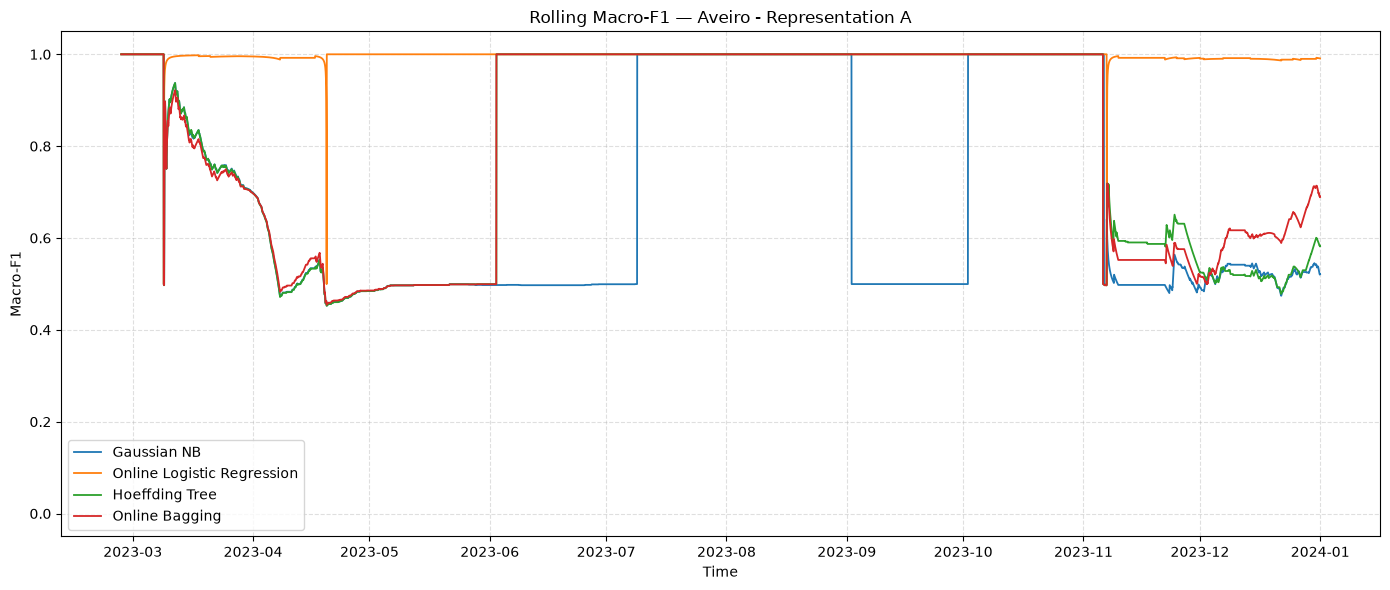

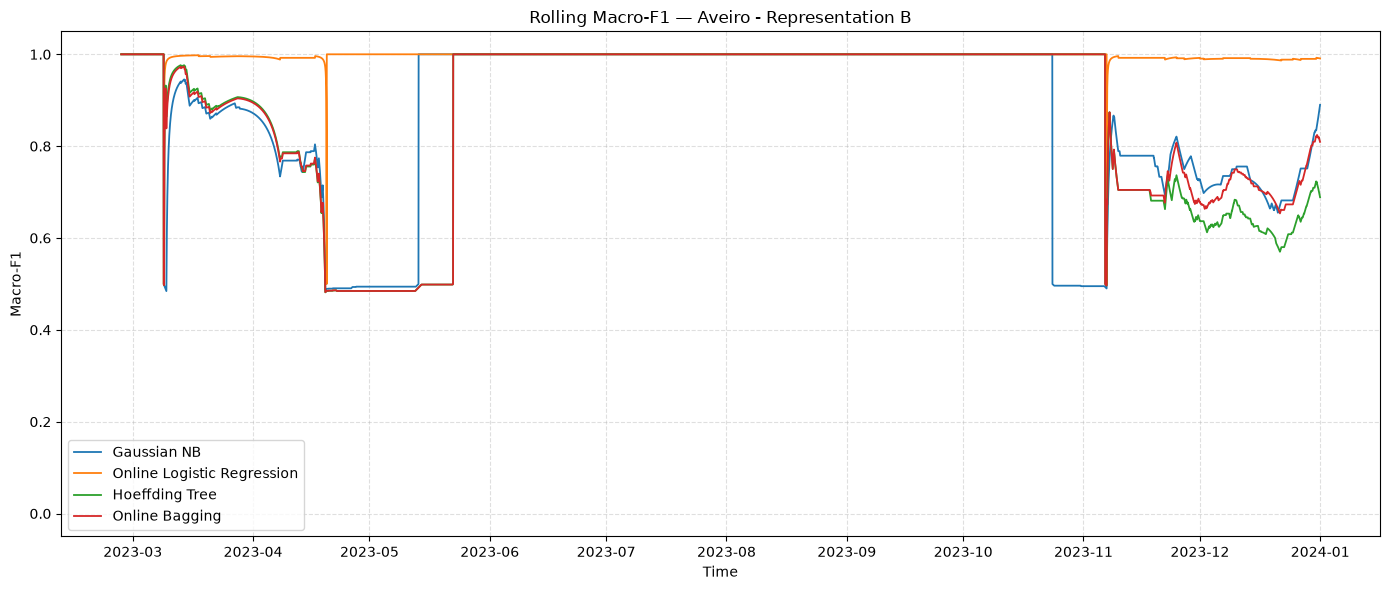

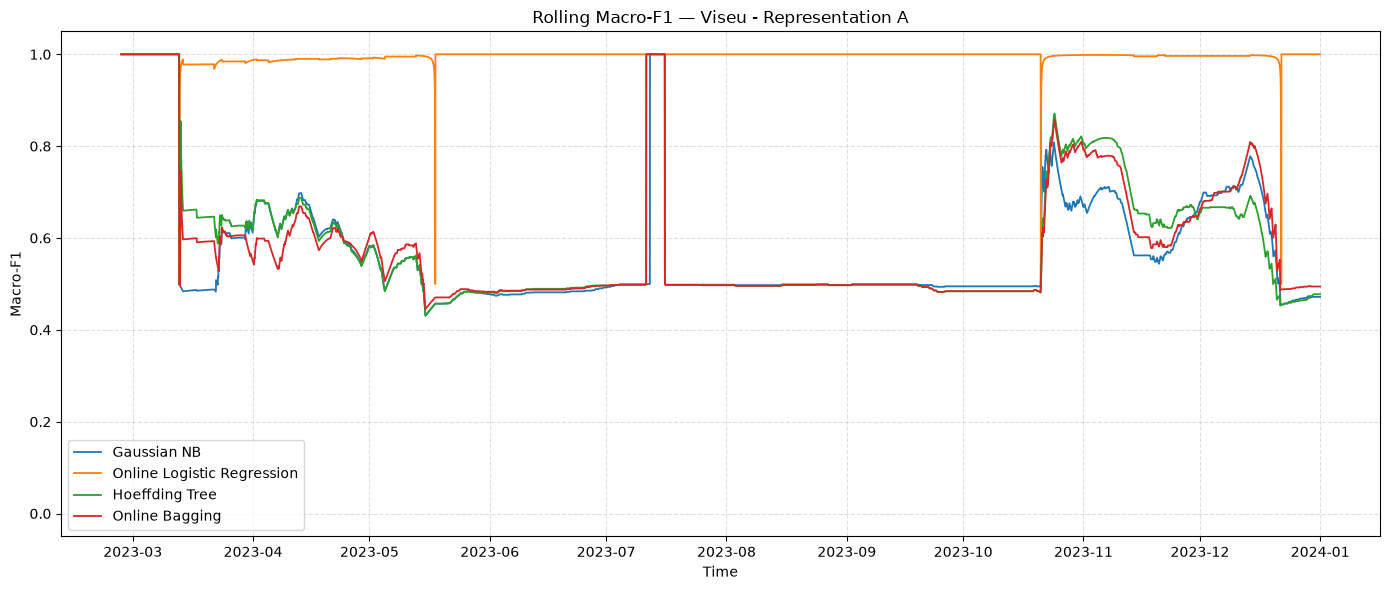

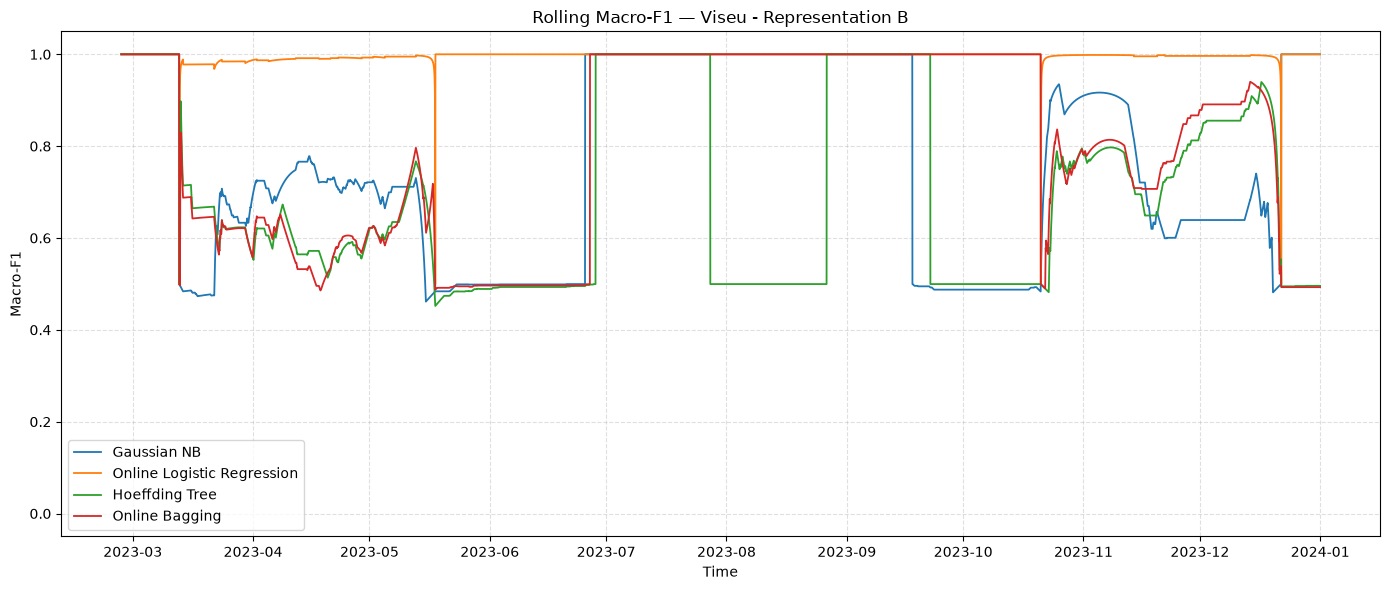

In [17]:
def plot_online_performance(
    history: pd.DataFrame,
    title: str,
):
    fig, ax = plt.subplots(figsize=(14, 6))

    metric_columns = [
        column
        for column in history.columns
        if column.endswith("rolling_macro_f1")
    ]

    for column in metric_columns:
        ax.plot(
            history["time"],
            history[column],
            label=column.replace(" | rolling_macro_f1", ""),
            linewidth=1.3,
        )

    ax.set_title(f"Rolling Macro-F1 — {title}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Macro-F1")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    fig.tight_layout()
    plt.show()

for name, history in experiments.items():
    plot_online_performance(history, name)

### Compare the features representations

representation                         A      B
city   model                                   
Aveiro Gaussian NB                 0.770  0.915
       Hoeffding Tree              0.798  0.884
       Online Bagging              0.835  0.904
       Online Logistic Regression  0.997  0.997
Viseu  Gaussian NB                 0.851  0.916
       Hoeffding Tree              0.863  0.900
       Online Bagging              0.873  0.908
       Online Logistic Regression  0.998  0.998

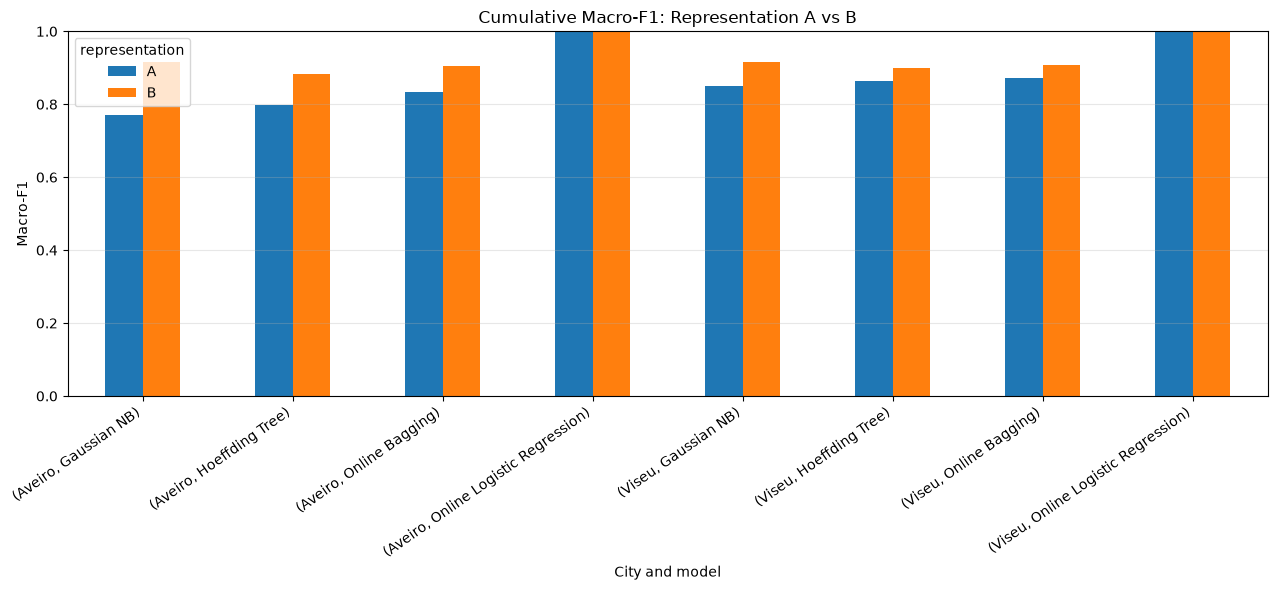

In [18]:
macro_f1_comparison = comparison.pivot_table(
    index=["city", "model"],
    columns="representation",
    values="macro_f1",
)

display(macro_f1_comparison.round(3))

ax = macro_f1_comparison.plot(
    kind="bar",
    figsize=(13, 6),
)

ax.set_title("Cumulative Macro-F1: Representation A vs B")
ax.set_xlabel("City and model")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Track incremental mean temperature

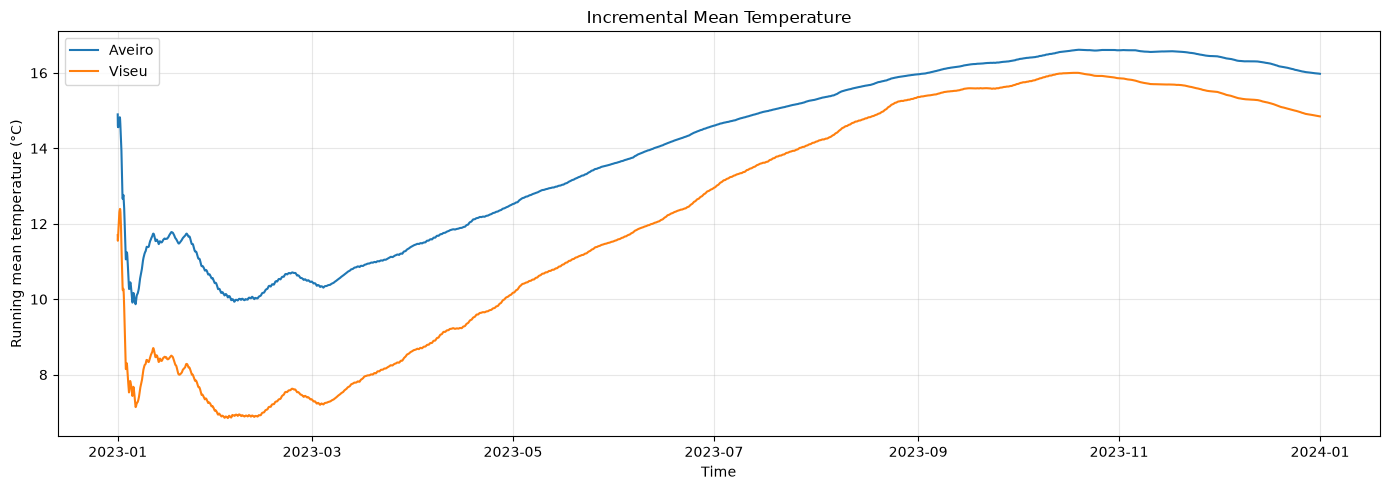

In [19]:
def track_incremental_mean(
    df: pd.DataFrame,
) -> pd.DataFrame:
    running_mean = stats.Mean()
    records = []

    for row in df.sort_values("time").itertuples(index=False):
        running_mean.update(float(row.temperature))

        records.append({
            "time": row.time,
            "temperature": row.temperature,
            "running_mean": running_mean.get(),
        })

    return pd.DataFrame(records)


mean_results = {
    city: track_incremental_mean(df)
    for city, df in clean_data.items()
}

fig, ax = plt.subplots(figsize=(14, 5))

for city, result in mean_results.items():
    ax.plot(
        result["time"],
        result["running_mean"],
        label=city,
    )

ax.set_title("Incremental Mean Temperature")
ax.set_xlabel("Time")
ax.set_ylabel("Running mean temperature (°C)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# UNCLEAN

In [5]:
# Define the folders used to store the data.
# parents=True creates any missing parent directories.
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


def fetch_open_meteo_data(
    latitude: float,
    longitude: float,
    start_date: str,
    end_date: str,
    city_name: str,
) -> pd.DataFrame:
    """Fetch weather data and save raw and processed versions."""

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "wind_speed_10m",
        ],
        "timezone": "Europe/Lisbon",
    }

    # Request the data from the API.
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    # --------------------------------------------------
    # 1. RAW LAYER: save the original API response.
    # --------------------------------------------------
    raw_path = RAW_DIR / f"{city_name.lower()}.json"

    with raw_path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2)

    # --------------------------------------------------
    # 2. PROCESSED LAYER: prepare the analysis table.
    # --------------------------------------------------

    # Extract hourly observations into a DataFrame.
    df = pd.DataFrame(data["hourly"])

    # Convert the timestamp column into datetime objects.
    df["time"] = pd.to_datetime(df["time"])

    # Add the city identifier.
    df["city"] = city_name

    # Rename the variables to simpler column names.
    df.rename(
        columns={
            "temperature_2m": "temperature",
            "relative_humidity_2m": "humidity",
            "wind_speed_10m": "wind_speed",
        },
        inplace=True,
    )

    # Sort observations chronologically.
    df.sort_values(by="time", inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Save the processed table separately.
    processed_path = PROCESSED_DIR / f"{city_name.lower()}.csv"
    df.to_csv(processed_path, index=False)

    return df


# Define the historical period.
START_DATE = "2023-01-01"
END_DATE = "2023-12-31"

# Fetch, save, and process the data for both cities.
df_aveiro = fetch_open_meteo_data(
    40.6405, -8.6538, START_DATE, END_DATE, "Aveiro"
)

df_viseu = fetch_open_meteo_data(
    40.6572, -7.9142, START_DATE, END_DATE, "Viseu"
)

# <font color='#BFD72F' size=6>**2. Data Understanding**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

### <font size=6>2.1 Visualization</font> <a class="anchor" id="3.3.4"></a>
  
[Back to TOC](#toc)

In [6]:
df_viseu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           8760 non-null   datetime64[ns]
 1   temperature    8760 non-null   float64       
 2   humidity       8760 non-null   int64         
 3   precipitation  8760 non-null   float64       
 4   wind_speed     8760 non-null   float64       
 5   city           8760 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 410.8+ KB


In [7]:
df_viseu

,time,temperature,humidity,precipitation,wind_speed,city
0,2023-01-01 00:00:00,11.7,91,2.1,18.6,Viseu
1,2023-01-01 01:00:00,11.4,91,1.1,16.4,Viseu
2,2023-01-01 02:00:00,11.7,88,0.6,19.6,Viseu
3,2023-01-01 03:00:00,11.9,86,0.1,20.8,Viseu
4,2023-01-01 04:00:00,12.1,84,0.0,21.7,Viseu
...,...,...,...,...,...,...
8755,2023-12-31 19:00:00,7.8,77,0.0,6.8,Viseu
8756,2023-12-31 20:00:00,6.9,80,0.0,5.6,Viseu
8757,2023-12-31 21:00:00,6.0,85,0.0,7.3,Viseu
8758,2023-12-31 22:00:00,5.4,87,0.0,6.3,Viseu


### <font size=6>2.1 Missing Values</font> <a class="anchor" id="3.3.4"></a>
  
[Back to TOC](#toc)

In [8]:
# 3. Check for duplicate times
duplicates_aveiro = df_aveiro["time"].duplicated().sum()
duplicates_viseu = df_viseu["time"].duplicated().sum()

print(f"Aveiro duplicate times: {duplicates_aveiro}")
print(f"Viseu duplicate time: {duplicates_viseu}")

Aveiro duplicate times: 0
Viseu duplicate time: 0


In [9]:
# Check the number of missing values in each column
print("Missing values - Aveiro:")
print(df_aveiro.isna().sum())

print("\nMissing values - Viseu:")
print(df_viseu.isna().sum())

Missing values - Aveiro:
time             0
temperature      0
humidity         0
precipitation    0
wind_speed       0
city             0
dtype: int64

Missing values - Viseu:
time             0
temperature      0
humidity         0
precipitation    0
wind_speed       0
city             0
dtype: int64


In [10]:
def check_missing_days(df, name):
    # Extract only the calendar date from the timestamp
    dates = df["time"].dt.normalize()

    # Create every calendar day between the first and last observation
    expected_dates = pd.date_range(
        start=dates.min(),
        end=dates.max(),
        freq="D"
    )

    # Find days that are not present in the dataset
    missing_dates = expected_dates.difference(dates)

    print(f"{name}:")
    
    if len(missing_dates) == 0:
        print("No missing days.")
    else:
        print(f"Missing days: {len(missing_dates)}")
        print(missing_dates)


check_missing_days(df_aveiro, "Aveiro")
check_missing_days(df_viseu, "Viseu")

Aveiro:
No missing days.
Viseu:
No missing days.


### <font size=6>2.2 Inconsistencies / Invalid values</font> <a class="anchor" id="3.3.4"></a>

#### make pretty
[Back to TOC](#toc)

In [11]:
# Select the core continuous weather variables
variables = ['temperature', 'humidity', 'precipitation', 'wind_speed']


def get_descriptive_summary(df: pd.DataFrame, city_name: str) -> pd.DataFrame:
  """Calculates Min, Max, Mean, Std, and Quantiles for weather stream variables."""
  stats = df[variables].agg(['min', 'max', 'mean', 'std']).T
  stats.columns = ['Min', 'Max', 'Mean', 'Std']

  # Add 20th and 80th percentiles for warm-up / threshold context
  stats['Q20 (20%)'] = df[variables].quantile(0.20)
  stats['Q50 (Median)'] = df[variables].quantile(0.50)
  stats['Q80 (80%)'] = df[variables].quantile(0.80)

  stats.insert(0, 'City', city_name)
  return stats.round(2)


# Compute for both clean datasets
summary_aveiro = get_descriptive_summary(df_aveiro, 'Aveiro')
summary_viseu = get_descriptive_summary(df_viseu, 'Viseu')

# Combine into one table
full_summary = pd.concat([summary_aveiro, summary_viseu])
print(full_summary)

                 City   Min    Max   Mean    Std  Q20 (20%)  Q50 (Median)  \
temperature    Aveiro   0.1   33.2  15.98   4.93       12.0          16.5   
humidity       Aveiro  21.0  100.0  80.40  15.61       67.0          84.0   
precipitation  Aveiro   0.0   15.5   0.13   0.61        0.0           0.0   
wind_speed     Aveiro   0.0   48.3  13.63   8.10        6.2          12.3   
temperature     Viseu  -2.5   40.2  14.85   7.12        8.8          14.3   
humidity        Viseu  13.0  100.0  72.53  21.50       53.0          77.0   
precipitation   Viseu   0.0   12.7   0.14   0.61        0.0           0.0   
wind_speed      Viseu   0.0   41.3  10.12   6.03        4.8           8.8   

               Q80 (80%)  
temperature         20.0  
humidity            94.0  
precipitation        0.0  
wind_speed          20.2  
temperature         20.8  
humidity            94.0  
precipitation        0.0  
wind_speed          15.4  


### <font size=6>2.3 Create Target Variable</font> <a class="anchor" id="3.3.4"></a>

In [16]:
df_viseu["target"] = 0
df_aveiro["target"] = 0

## Stream

In [17]:
def dataframe_replay_stream(
    df,
    timestamp_col,
    feature_cols,
    target_col=None
):
    """Yield timestamped observations one at a time."""

    ordered = df.sort_values(timestamp_col)

    for _, row in ordered.iterrows():
        timestamp = row[timestamp_col]

        x = {
            col: row[col]
            for col in feature_cols
            if col in row.index and pd.notna(row[col])
        }

        if target_col is None:
            yield timestamp, x
        else:
            y = row[target_col]
            yield timestamp, x, y

features = ['temperature', 'humidity', 'precipitation', 'wind_speed']

if not df_aveiro.empty:
    stream_aveiro = dataframe_replay_stream(
        df_aveiro,
        timestamp_col="time",
        feature_cols=features,
        target_col="target"
    )

    for i, observation in enumerate(stream_aveiro):
        print(observation)

        if i >= 4:
            break

(Timestamp('2023-01-01 00:00:00'), {'temperature': 14.9, 'humidity': 91, 'precipitation': 3.2, 'wind_speed': 23.2}, 0)
(Timestamp('2023-01-01 01:00:00'), {'temperature': 14.3, 'humidity': 90, 'precipitation': 2.2, 'wind_speed': 17.4}, 0)
(Timestamp('2023-01-01 02:00:00'), {'temperature': 14.5, 'humidity': 88, 'precipitation': 3.8, 'wind_speed': 21.8}, 0)
(Timestamp('2023-01-01 03:00:00'), {'temperature': 14.6, 'humidity': 84, 'precipitation': 0.5, 'wind_speed': 26.2}, 0)
(Timestamp('2023-01-01 04:00:00'), {'temperature': 14.5, 'humidity': 82, 'precipitation': 0.2, 'wind_speed': 26.3}, 0)


- Ver distribuição do target

## TENTATIVA

PHYSICAL_BOUNDS = {
    "temperature": (-10.0, 50.0),   # °C
    "humidity": (0.0, 100.0),       # %
    "precipitation": (0.0, 150.0),  # mm/h
    "wind_speed": (0.0, 150.0)      # km/h
}

def audit_and_clean_stream(df: pd.DataFrame, city_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Audits physical bounds and handles missing values without removing genuine extreme events.
    """
    df_clean = df.copy()
    audit_logs = []
    
    # Ensure chronology
    df_clean["time"] = pd.to_datetime(df_clean["time"])
    df_clean.sort_values(by="time", inplace=True)
    df_clean.reset_index(drop=True, inplace=True)
    
    # Identify impossible values and set to NaN
    for col, (min_val, max_val) in PHYSICAL_BOUNDS.items():
        invalid_mask = (df_clean[col] < min_val) | (df_clean[col] > max_val)
        invalid_count = invalid_mask.sum()
        if invalid_count > 0:
            audit_logs.append({
                "city": city_name,
                "variable": col,
                "issue": f"Out of physical bounds [{min_val}, {max_val}]",
                "count": invalid_count
            })
            df_clean.loc[invalid_mask, col] = np.nan
            
    # Forward-fill missing/corrupted values to preserve stream temporal order
    df_clean[list(PHYSICAL_BOUNDS.keys())] = df_clean[list(PHYSICAL_BOUNDS.keys())].ffill().bfill()
    
    return df_clean, pd.DataFrame(audit_logs)

df_aveiro_clean, audit_aveiro = audit_and_clean_stream(df_aveiro, "Aveiro")
df_viseu_clean, audit_viseu = audit_and_clean_stream(df_viseu, "Viseu")

#audit_summary = pd.concat([audit_aveiro, audit_viseu], ignore_index=True)
#audit_summary.to_csv("data/data_quality_audit.csv", index=False)


## Voltar ao trabalho

In [13]:
# 1. Define warm-up length (first 15% of the data)
WARMUP_PERCENTAGE = 0.15
warmup_len = int(len(df_aveiro) * WARMUP_PERCENTAGE)

# 2. Pool warm-up temperature data from both cities
pooled_warmup_temp = pd.concat(
    [df_aveiro["temperature"].iloc[:warmup_len], df_viseu["temperature"].iloc[:warmup_len]]
)

# 3. Calculate and freeze the 80th percentile threshold (tau_T_hot)
TAU_T_HOT = float(pooled_warmup_temp.quantile(0.80))

print(f"TAU_T_HOT is now defined: {TAU_T_HOT:.2f} °C")

TAU_T_HOT is now defined: 12.90 °C


In [14]:
# Defined strictly on current temperature and the frozen threshold
df_aveiro["target"] = (df_aveiro["temperature"] >= TAU_T_HOT).astype(int)
df_viseu["target"] = (df_viseu["temperature"] >= TAU_T_HOT).astype(int)

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from river import (
    compose,
    ensemble,
    linear_model,
    metrics,
    naive_bayes,
    tree,
    utils,
)


# ==============================================================================
# 1. FETCH RAW DATA FROM OPEN-METEO API
# ==============================================================================

def fetch_open_meteo_data(
    latitude: float,
    longitude: float,
    start_date: str,
    end_date: str,
    city_name: str,
) -> pd.DataFrame:
    """Fetches historical hourly weather data for a given city from Open-Meteo API."""

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "wind_speed_10m",
        ],
        "timezone": "Europe/Lisbon",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    df = pd.DataFrame(data["hourly"])

    df["time"] = pd.to_datetime(df["time"])
    df["city"] = city_name

    df.rename(
        columns={
            "temperature_2m": "temperature",
            "relative_humidity_2m": "humidity",
            "precipitation": "precipitation",
            "wind_speed_10m": "wind_speed",
        },
        inplace=True,
    )

    df.sort_values(by="time", inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


START_DATE = "2023-01-01"
END_DATE = "2023-12-31"


print("1. Fetching raw streams from Open-Meteo...")

df_aveiro_raw = fetch_open_meteo_data(
    40.6405,
    -8.6538,
    START_DATE,
    END_DATE,
    "Aveiro",
)

df_viseu_raw = fetch_open_meteo_data(
    40.6572,
    -7.9142,
    START_DATE,
    END_DATE,
    "Viseu",
)


# ==============================================================================
# 2. AUDIT & IMPUTE DATA QUALITY
# ==============================================================================

PHYSICAL_BOUNDS = {
    "temperature": (-10.0, 50.0),
    "humidity": (0.0, 100.0),
    "precipitation": (0.0, 150.0),
    "wind_speed": (0.0, 150.0),
}


def audit_and_clean_stream(
    df: pd.DataFrame,
    city_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    df_clean = df.copy()
    audit_logs = []

    df_clean["time"] = pd.to_datetime(df_clean["time"])

    df_clean.sort_values(
        by="time",
        inplace=True,
    )

    df_clean.reset_index(
        drop=True,
        inplace=True,
    )

    for col, (min_val, max_val) in PHYSICAL_BOUNDS.items():

        invalid_mask = (
            (df_clean[col] < min_val)
            | (df_clean[col] > max_val)
        )

        invalid_count = invalid_mask.sum()

        if invalid_count > 0:

            audit_logs.append(
                {
                    "city": city_name,
                    "variable": col,
                    "issue": (
                        f"Out of bounds "
                        f"[{min_val}, {max_val}]"
                    ),
                    "count": invalid_count,
                }
            )

            df_clean.loc[
                invalid_mask,
                col,
            ] = np.nan

    weather_columns = list(PHYSICAL_BOUNDS.keys())

    df_clean[weather_columns] = (
        df_clean[weather_columns]
        .ffill()
        .bfill()
    )

    return (
        df_clean,
        pd.DataFrame(audit_logs),
    )


df_aveiro_clean, aveiro_audit = audit_and_clean_stream(
    df_aveiro_raw,
    "Aveiro",
)

df_viseu_clean, viseu_audit = audit_and_clean_stream(
    df_viseu_raw,
    "Viseu",
)


# Optional: display audit results

print("\nData quality audit - Aveiro:")
print(aveiro_audit)

print("\nData quality audit - Viseu:")
print(viseu_audit)


# ==============================================================================
# 3. WARM-UP THRESHOLD & FEATURE REPRESENTATIONS
# ==============================================================================

WARMUP_PERCENTAGE = 0.15

warmup_len = int(
    len(df_aveiro_clean) * WARMUP_PERCENTAGE
)


pooled_warmup_temp = pd.concat(
    [
        df_aveiro_clean["temperature"].iloc[:warmup_len],
        df_viseu_clean["temperature"].iloc[:warmup_len],
    ]
)


TAU_T_HOT = float(
    pooled_warmup_temp.quantile(0.80)
)


print(
    f"\n2. Frozen Target Threshold "
    f"(tau_T_hot): {TAU_T_HOT:.2f} °C"
)


def prepare_stream_features(
    df: pd.DataFrame,
    tau_threshold: float,
) -> pd.DataFrame:

    df_feat = df.copy()

    # --------------------------------------------------------------------------
    # Target T2
    # --------------------------------------------------------------------------

    df_feat["target"] = (
        df_feat["temperature"] >= tau_threshold
    ).astype(int)

    # --------------------------------------------------------------------------
    # Representation A: Lagged variables (t-1)
    # --------------------------------------------------------------------------

    df_feat["temp_lag1"] = (
        df_feat["temperature"].shift(1)
    )

    df_feat["humidity_lag1"] = (
        df_feat["humidity"].shift(1)
    )

    df_feat["precipitation_lag1"] = (
        df_feat["precipitation"].shift(1)
    )

    df_feat["wind_speed_lag1"] = (
        df_feat["wind_speed"].shift(1)
    )

    # --------------------------------------------------------------------------
    # Representation B: Stream-aware aggregations
    # --------------------------------------------------------------------------

    df_feat["delta_temp"] = (
        df_feat["temp_lag1"]
        - df_feat["temperature"].shift(2)
    )

    df_feat["rolling_mean_temp_6h"] = (
        df_feat["temp_lag1"]
        .rolling(window=6)
        .mean()
    )

    df_feat["rolling_std_temp_6h"] = (
        df_feat["temp_lag1"]
        .rolling(window=6)
        .std()
        .fillna(0)
    )

    df_feat["rolling_mean_temp_24h"] = (
        df_feat["temp_lag1"]
        .rolling(window=24)
        .mean()
    )

    lagged_heat_events = (
        df_feat["temp_lag1"] >= tau_threshold
    ).astype(int)

    df_feat["heat_events_last_24h"] = (
        lagged_heat_events
        .rolling(window=24)
        .sum()
    )

    # Remove rows containing NaN values created by lagging/rolling windows

    df_feat.dropna(
        inplace=True
    )

    df_feat.reset_index(
        drop=True,
        inplace=True,
    )

    return df_feat


# ------------------------------------------------------------------------------
# Define feature streams
# ------------------------------------------------------------------------------

df_aveiro_stream = prepare_stream_features(
    df_aveiro_clean,
    TAU_T_HOT,
)

df_viseu_stream = prepare_stream_features(
    df_viseu_clean,
    TAU_T_HOT,
)


FEATURE_COLS_A = [
    "temp_lag1",
    "humidity_lag1",
    "precipitation_lag1",
    "wind_speed_lag1",
]


FEATURE_COLS_B = FEATURE_COLS_A + [
    "delta_temp",
    "rolling_mean_temp_6h",
    "rolling_std_temp_6h",
    "rolling_mean_temp_24h",
    "heat_events_last_24h",
]


# ==============================================================================
# 4. PREQUENTIAL SLIDING-WINDOW EVALUATION & DRIFT PLOTS
# ==============================================================================

WINDOW_SIZE = 720  # 30-day sliding window (720 hours)


def track_sliding_performance(
    df_stream: pd.DataFrame,
    feature_cols: list[str],
) -> pd.DataFrame:

    # --------------------------------------------------------------------------
    # Define online learning models
    # --------------------------------------------------------------------------

    models = {
        "Gaussian NB": naive_bayes.GaussianNB(),

        "Online Logistic Regression": compose.Pipeline(
            linear_model.LogisticRegression()
        ),

        "Hoeffding Tree": tree.HoeffdingTreeClassifier(),

        "Online Bagging": ensemble.BaggingClassifier(
        model=tree.HoeffdingTreeClassifier(),
        seed=42,),
    }

    # --------------------------------------------------------------------------
    # Sliding-window Macro-F1 evaluators
    # --------------------------------------------------------------------------

    sliding_evaluators = {
        name: utils.Rolling(
            metrics.MacroF1(),
            window_size=WINDOW_SIZE,
        )
        for name in models
    }

    history = []

    # --------------------------------------------------------------------------
    # Prequential evaluation
    # --------------------------------------------------------------------------

    for idx, row in df_stream.iterrows():

        x = row[
            feature_cols
        ].to_dict()

        y = int(
            row["target"]
        )

        timestamp = (
            row["time"]
            if "time" in row
            else idx
        )

        row_history = {
            "time": timestamp
        }

        # ----------------------------------------------------------------------
        # Predict -> evaluate -> learn
        # ----------------------------------------------------------------------

        for name, model in models.items():

            y_pred = model.predict_one(x)

            if y_pred is not None:

                sliding_evaluators[name].update(
                    y,
                    y_pred,
                )

                row_history[name] = (
                    sliding_evaluators[name].get()
                )

            else:

                row_history[name] = None

            # Learn only AFTER prediction
            model.learn_one(
                x,
                y,
            )

        history.append(
            row_history
        )

    return pd.DataFrame(
        history
    )


# ==============================================================================
# 5. PLOT PREQUENTIAL DRIFT
# ==============================================================================

def plot_prequential_drift(
    df_history: pd.DataFrame,
    title: str,
):

    plt.figure(
        figsize=(14, 6)
    )

    model_names = [
        col
        for col in df_history.columns
        if col != "time"
    ]

    for name in model_names:

        plt.plot(
            df_history["time"],
            df_history[name],
            label=name,
            linewidth=(
                1.8
                if "Adaptive" in name
                else 1.2
            ),
            alpha=(
                0.9
                if "Adaptive" in name
                else 0.7
            ),
        )

    plt.title(
        (
            "Prequential Sliding-Window "
            f"Macro-F1 (Window = {WINDOW_SIZE}h) "
            f"- {title}"
        ),
        fontsize=13,
        pad=10,
    )

    plt.xlabel(
        "Timeline",
        fontsize=11,
    )

    plt.ylabel(
        "Macro-F1 Score",
        fontsize=11,
    )

    plt.ylim(
        -0.05,
        1.05,
    )

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5,
    )

    plt.legend(
        loc="lower right",
        frameon=True,
        facecolor="white",
        edgecolor="none",
    )

    plt.tight_layout()

    plt.show()


# ==============================================================================
# 6. RUN AND VISUALIZE
# ==============================================================================

print(
    "\n3. Tracking sliding performance "
    "for Aveiro (Representation B)..."
)

history_aveiro_b = track_sliding_performance(
    df_aveiro_stream,
    FEATURE_COLS_B,
)

plot_prequential_drift(
    history_aveiro_b,
    "Aveiro (Representation B)",
)


print(
    "\n4. Tracking sliding performance "
    "for Viseu (Representation B)..."
)

history_viseu_b = track_sliding_performance(
    df_viseu_stream,
    FEATURE_COLS_B,
)

plot_prequential_drift(
    history_viseu_b,
    "Viseu (Representation B)",
)


# ==============================================================================
# 7. OPTIONAL: FINAL PERFORMANCE SUMMARY
# ==============================================================================

print("\nFinal Macro-F1 scores - Aveiro:")

print(
    history_aveiro_b.drop(
        columns=["time"]
    ).iloc[-1]
)


print("\nFinal Macro-F1 scores - Viseu:")

print(
    history_viseu_b.drop(
        columns=["time"]
    ).iloc[-1]
)



KeyboardInterrupt: 